#### Name: Jon Stowers

# PHYS 230 Lab Assignment 17

### Wednesday, April 8, 2026: Chapter 10.1
- Random numbers

In [1]:
# import statements here
import numpy as np
import matplotlib.pyplot as plt
import random

## Part 1: Testing random number generators

#### Step 1: Write a function `LCM_random(a,c,m,N,x)` that generates a list of $N$ random numbers using the linear congruent method from a starting seed $x$. 

In [ ]:
def LCM_random(a,c,m,N,x):
    #our generated numbers will be stored in a list
    vals = []
    #loop through to create the list
    for _ in range(N):
        x = (a*x + c) % m
        vals.append(x)
    #return the list
    return vals


#### Step 2: Call on your function from step 1 using the most accepted values of the constants $a,c$, and $m$, and whatever you want to use as the seed. Create an array $r$ of 1000 points. Repeat testing at least three different seeds total. 

In [3]:
#define our constants
a = 1664525 #best value for a
c = 1013904223 #best value for c
m = 4294967296 #best value for m

x1 = 10 #seed (chosen through rigorous research and examination and because Ben Maxwell told me to use these)
x2 = 15
x3 = 4


N = 1000 #points

r1 = LCM_random(a,c,m,N,x1)
r2 = LCM_random(a,c,m,N,x2)
r3 = LCM_random(a,c,m,N,x3)



### <font color='purple'> Comments </font> 

<font color='purple'> great! </font> 


#### Step 3: Make a plot (or separate plots may be best) of your arrays using Matplotlib Pyplot (simply feed in a single 1D array) to see how random the data truly is. In a markdown cell, explain any differences you notice when you use different seed values. 

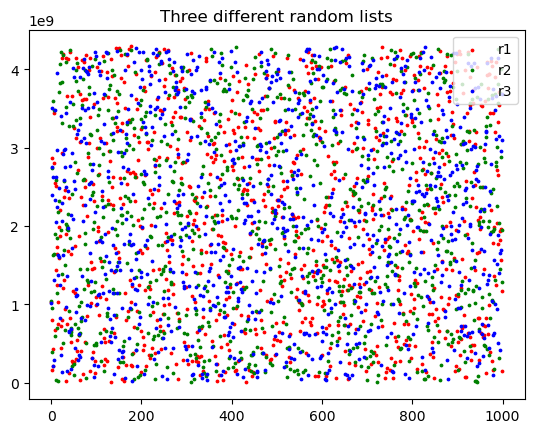

In [4]:
plt.scatter(range(1000),r1,s=3,c='r',label='r1')
plt.scatter(range(1000),r2,s=3,c='g',label='r2')
plt.scatter(range(1000),r3,s=3,c='b',label='r3')
plt.title('Three different random lists')
plt.legend()
plt.show()

The data does appear random for all three seeds. Since my seeds are all rather close to one another in magnitude, the initial values are not changed much, but I suspect changing the initial value should affect the points close to zero, before the values become harder to predict.

#### Step 4: Make a plot of successive random numbers for one of your arrays, where your plot points should be ($x,y$) = ($r_i$, $r_{i+1}$). What do you notice about this plot? Do the values truly seem random? 

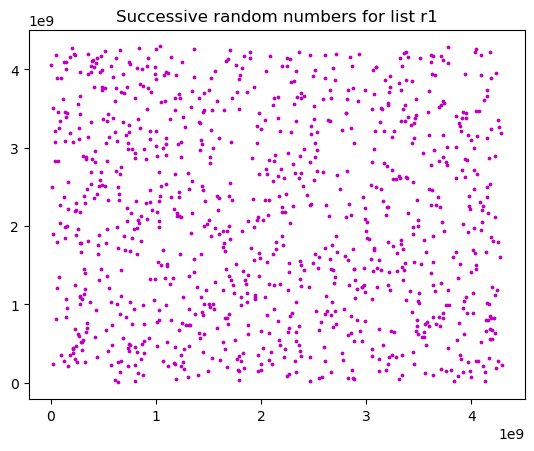

In [6]:
plt.scatter(r1[0:998],r1[1:999],s=3,c='m')
plt.title('Successive random numbers for list r1')
plt.show()

The values do truly seem random according to this plot! I cannot see a pattern in this graph.

### <font color='purple'> Comments </font> 

<font color='purple'>nice analysis! </font> 


#### Step 5: Now try an unwise choice of constant for the linear congruent method. Try using $(a,c,m,x) = (57,1,256,10)$ to generate 1000 random values. Make a 1D plot and also the plot (x,y) = ($r_i$, $r_{i+1}$). Explain what you notice about these plots compared to above. 

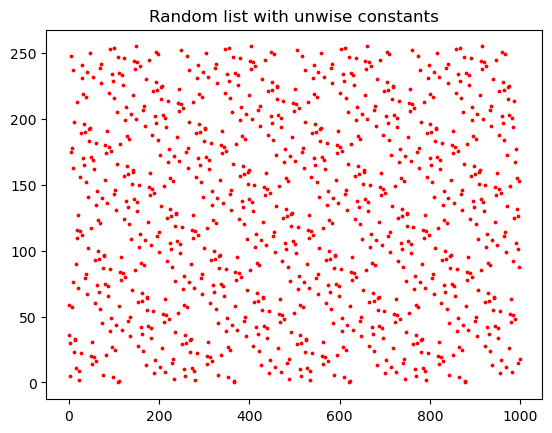

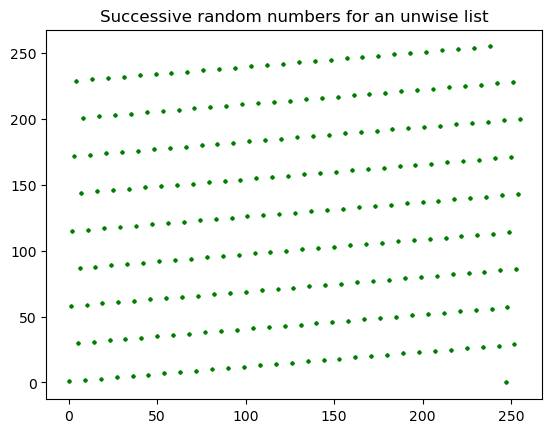

In [7]:

r_unwise = LCM_random(57,1,256,N,10)



plt.scatter(range(1000),r_unwise,s=3,c='r')
plt.title('Random list with unwise constants')
plt.show()

plt.scatter(r_unwise[0:998],r_unwise[1:999],s=3,c='g')
plt.title('Successive random numbers for an unwise list')
plt.show()




These plots have a clear noticeable pattern. This is likely caused by the smaller "step sizes" a and c alongside the smaller modulo number m, causing the list to "repeat"more often than with the accepted constants.

#### Step 6: Use a built-in random number generator from the `random` package to create an array of 1000 points. Plot the results and compare as done in steps 3 and 4 above. (Don't forget to include a markdown with your comparison.) 

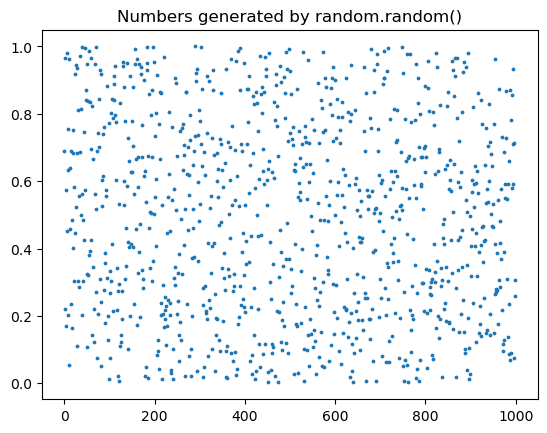

In [8]:



r_package = []
for _ in range(1000):
    r_package.append(random.random())

plt.scatter(range(1000),r_package,s=3)
plt.title('Numbers generated by random.random()')
plt.show()



I cannot tell the difference between the random package's numbers and the numbers generated using the linear congruential generator. So while I know the random package uses a more robust system, at this scale and with a visual analysis, they seem the same.

### <font color='purple'> Comments </font> 

<font color='purple'> great job! However, your commenting through is not consistent/lacking in many cells</font> 


## Part 2: Luck & Roulette 
(background information taken from [Wikipedia](https://en.wikipedia.org/wiki/Roulette))

Roulette is a casino game named after the French word meaning little wheel. In the game, a player may choose to place a bet on a single number, various groupings of numbers, the color red or black, whether the number is odd or even, or if the numbers are high (19–36) or low (1–18).

To determine the winning number, a croupier spins a wheel in one direction, then spins a ball in the opposite direction around a tilted circular track running around the outer edge of the wheel. The ball eventually loses momentum, passes through an area of deflectors, and falls onto the wheel and into one of  thirty-eight colored and numbered pockets on the wheel.

As explained above, there are many betting options for Roulette, seen on the roulette table layout below. One of the most common bets is either red or black. 

In this part of the lab, we're going to use a random number generator to determine the odds of winning when a gambling soul chooses red. 


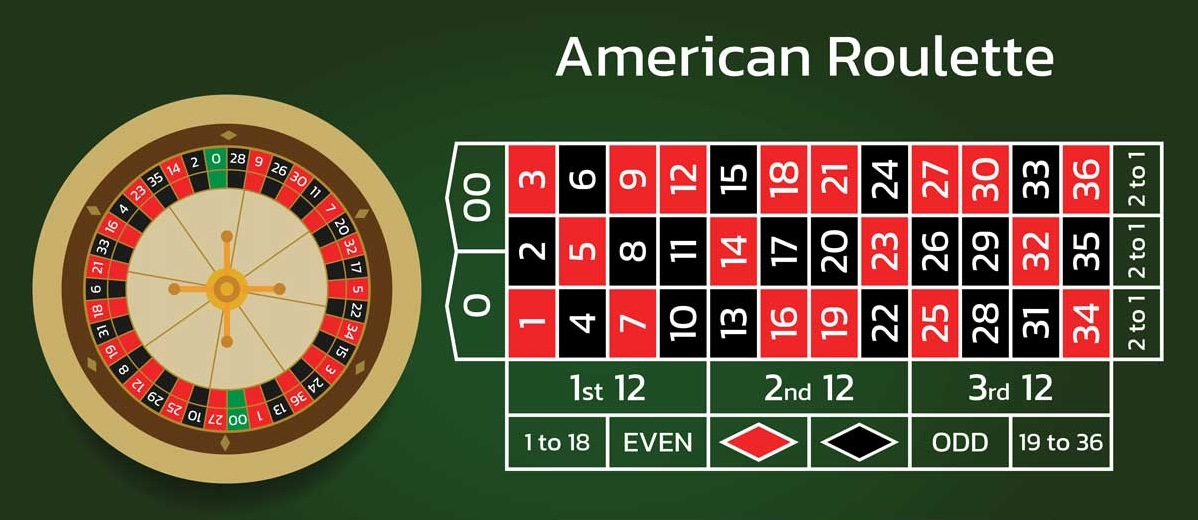

#### Step 1: Create two lists - `red` and `black` - which each contain all of the numbers that belong to those classifications. 

In [9]:

red = [1,3,5,7,9,12,14,16,18,19,21,23,25,27,30,32,34,36]
black = [2,4,6,8,10,11,13,15,17,20,22,24,26,28,29,31,33,35]

#### Step 2: Develop a *function* to spin the roulette wheel $N$ times. 

In the code it should: 
- create three variables (red_count, black_count, green_count) initially set equal to 0 (Green count will be used to keep track of 0 & 00)
- select a random number between 1 and 38 (37 and 38 are being used to represent 0 and 00 for this game)
- check if that number is in red or black list (or neither) - this would be best done with if, elif, and else
- if the number is red, black, or neither, add one to the corresponding variable from step 2. 

In [11]:

def spin(N):
    red_count = 0
    black_count = 0
    green_count = 0

    for _ in range(N):
        ball = random.randrange(1,39) #chooses an integer [1,38] where 37 is 0 and 38 is 00

        if ball in red:
            red_count += 1
        elif ball in black:
            black_count += 1
        else: 
            green_count += 1
    return red_count,black_count,green_count






#### Step 3: Call on your function to spin the roulette wheel 100, 1000, and 10,000 times. 

For each completion, determine what percentage of the spins were indeed red. 

In [13]:

N1 = 100
N2 = 1000
N3 = 10000

red1 = spin(N1)[0]
red1pct = red1/N1
print('For',N1,'spins, the result was red',red1pct,'percent of the time.')

red2 = spin(N2)[0]
red2pct = red2/N2
print('For',N2,'spins, the result was red',red2pct,'percent of the time.')

red3 = spin(N3)[0]
red3pct = red3/N3
print('For',N3,'spins, the result was red',red3pct,'percent of the time.')





For 100 spins, the result was red 0.48 percent of the time.
For 1000 spins, the result was red 0.461 percent of the time.
For 10000 spins, the result was red 0.4811 percent of the time.


#### Step 4: Vegas pays 1:1 for a red or black winning number, which would suggest you have a 50% chance of getting it right. Is this correct or is Vegas always putting the odds in their favor? Explain briefly. 

Our math determined the odds of rolling red is around 48%, so an assumption of 50/50 is higher than the actual likelihood of breaking even if you bet on red or black. To accurately reflect the odds of success, the payout should be slightly higher than 1:1.

### <font color='purple'> Comments </font> 

<font color='purple'> great job! nice analysis of the results and taking into account your numbers. But please remember to always put comments in your code</font> 
